## Predicting Freight Cost
**Objective:** Predict whether the vendor invoice should be flagged for manual approval based on abnormal cost, freight,or delivery patterns, in order to reduce financial risk, improve operational efficiency,and prioritize human review where it adds the most value. 

- Manual invoice review is time-consuming and does not scale with transaction volume.
- abnormal freight charges,pricing deviations delay often indicate errors, dispute, or compliance risks.
- An automated flagged system enables finance teams to focus attention on high risk invoice while allowing low risk invoice to be processed automatically.

In [90]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
conn = sqlite3.connect('../Data/inventory.db')

tables = pd.read_sql_query("select name from sqlite_master where type='table'",conn)
for table in tables['name']:
    print(f"Tables Name: {table}")
    display(pd.read_sql(f"select * from {table} limit 5", conn))

Tables Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Tables Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Tables Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Tables Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Tables Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [92]:
# aggregate purchase metrics
purchase_agg_df = pd.read_sql_query("""
    SELECT p.PONumber,
    COUNT(distinct p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars, 
    AVG(julianday(p.ReceivingDate)) - julianday(p.PODate) AS avg_receiving_delay        
    FROM purchases p
    GROUP BY p.PONumber
""",conn)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [93]:
# Fetch vendor invoice quantities, dollars, freight, and timing metrics.
pd.read_sql_query("""
    SELECT 
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS day_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
    FROM vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,day_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [94]:
purchase_agg_df.shape

(5543, 5)

In [95]:
# vendor invoice features for flagging — invoice amounts, freight, timing, and purchase aggregates
df = pd.read_sql_query("""
                  
WITH purchase_agg AS (
    SELECT 
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars, 
        AVG(julianday(p.ReceivingDate)) - julianday(p.PODate) AS avg_receiving_delay        
    FROM purchases p
    GROUP BY p.PONumber
    )
    
    SELECT 
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
        (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay
        
    FROM vendor_invoice vi
    LEFT JOIN purchase_agg pa
        ON vi.PONumber = pa.PONumber      
""",conn)

In [96]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [97]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [98]:
def create_invoice_risk_label(row):
    #invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

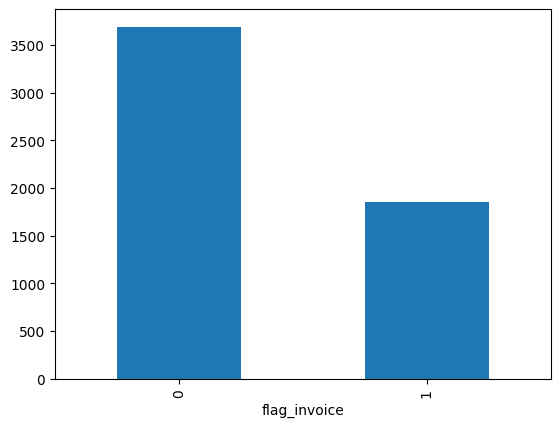

In [99]:
df['flag_invoice'].value_counts().plot(kind='bar')

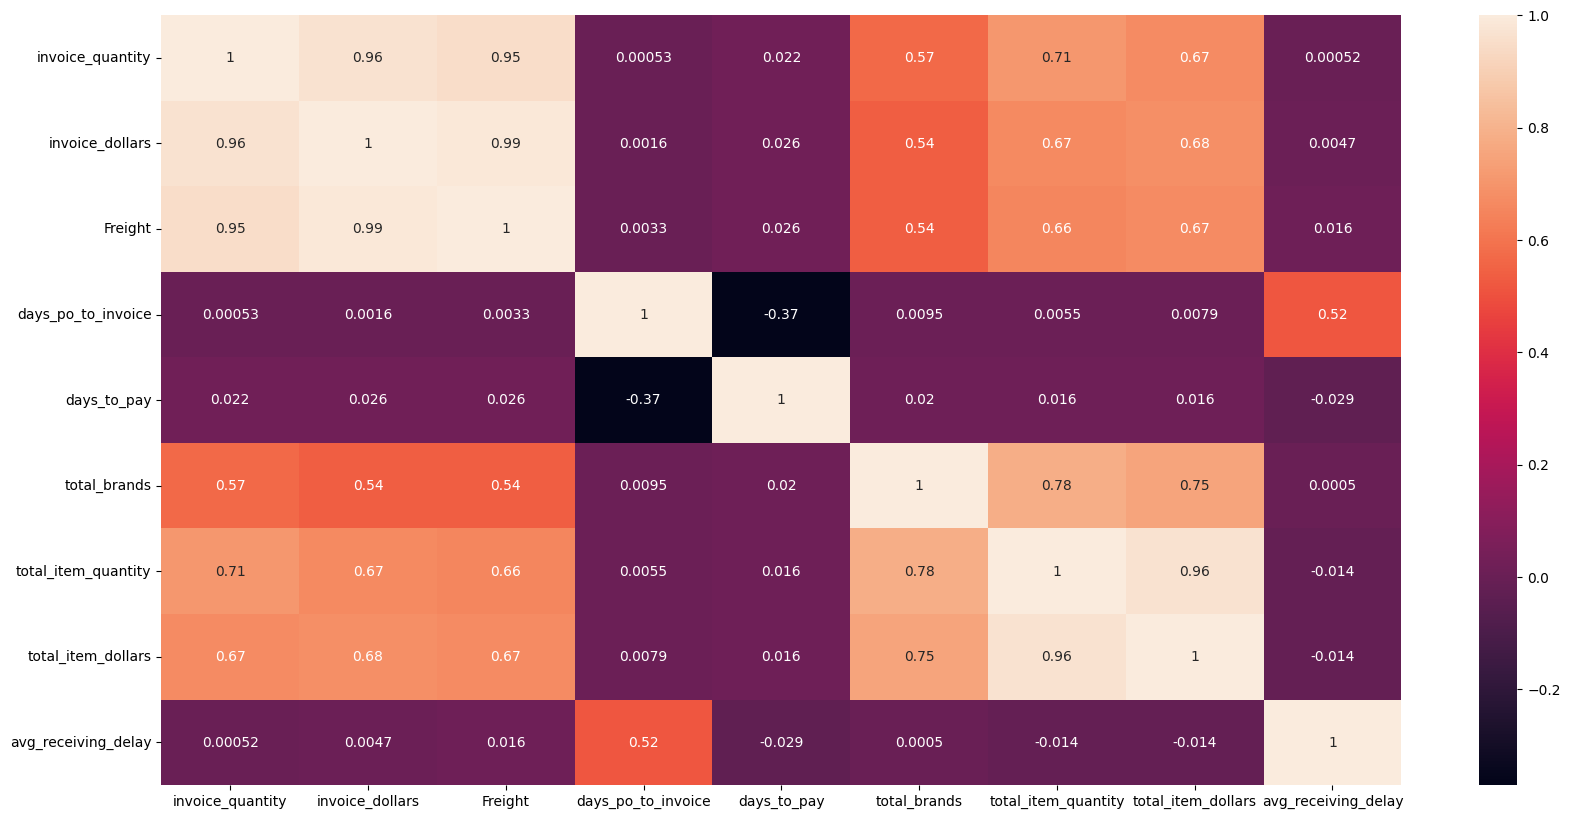

In [100]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()


In [101]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [102]:
significant_features = []
non_significant_feature = []
results = []

In [103]:
metrics = ['invoice_quantity','invoice_dollars','Freight',
           'days_po_to_invoice','days_to_pay','total_brands','total_item_quantity',
           'avg_receiving_delay']

In [104]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )
    if p_value < 0.05:
        significant_features.append(metric),
        results.append({
            "metric":metric,
            "flagged_mean":flagged_mean.round(2),
            "normal_mean":normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_feature.append(metric)
        print({
            "metric":metric,
            "flagged_mean":flagged_mean.round(2),
            "normal_mean":normal_mean.round(2),
            "p_value": p_value.round(3)
        })

{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [105]:
non_significant_feature

['days_to_pay', 'total_brands']

In [106]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'avg_receiving_delay']

In [107]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']

In [108]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0,8.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0,2.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0,3.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0,6.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0,8.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0,13.0


In [123]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [125]:
model1 = LogisticRegression(random_state = 42)
model1.fit(X_train_scaled,y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled,y_train)

model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [127]:
def evaluate_model(model, X_train_scaled,y_test, model_name:str)->dict:
    preds = model.predict(X_train_scaled)
    accuracy = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)
    print(f"\n{model_name} performance:")
    print(f"Accuracy:",accuracy * 100)
    print("Classification Report:")
    print(classification_report(y_test, preds))


In [128]:
evaluate_model(model1, x_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, x_test_scaled, y_test, "Decision Tree Classifier")


Logistic Regression performance:
Accuracy: 73.85031559963932
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.65      0.66      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree Classifier performance:
Accuracy: 94.67989179440937
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       725
           1       0.95      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109



In [129]:
evaluate_model(model3, x_test_scaled, y_test, "Random Forest Classifier")


Random Forest Classifier performance:
Accuracy: 95.40126239855726
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy                           0.95      1109
   macro avg       0.97      0.93      0.95      1109
weighted avg       0.96      0.95      0.95      1109



In [131]:
model3.feature_importances_

array([0.1135209 , 0.11407547, 0.0913245 , 0.05683138, 0.13538551,
       0.03010856, 0.15876104, 0.29999264])

In [133]:
feature_importance = pd.DataFrame({
    "Feature":X_train.columns,
    "importance":model3.feature_importances_
}).sort_values(by="importance",ascending=False)
feature_importance

,Feature,importance
7,avg_receiving_delay,0.299993
6,total_item_dollars,0.158761
4,total_item_quantity,0.135386
1,invoice_dollars,0.114075
0,invoice_quantity,0.113521
2,Freight,0.091325
3,total_brands,0.056831
5,days_po_to_invoice,0.030109


In [134]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars','avg_receiving_delay']]
y = df['flag_invoice']

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaling
scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [137]:
evaluate_model(model3, x_test_scaled, y_test, "Random Forest Classifier")


Random Forest Classifier performance:
Accuracy: 96.66366095581606
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.90      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109



In [146]:
from sklearn.metrics import make_scorer,f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[None,4,5,6],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion":['gini','entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, x_test_scaled, y_test, "Random Forest Classification")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0


Random Forest Classification performance:
Accuracy: 96.75383228133454
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.91      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109

